In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
import re
import sys
import nltk
import zipfile

from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC


In [2]:
# Import the dataset and convert to dataframe
# Place train.json in the same folder as this notebook before running
recipe = pd.read_json("train.json")
recipe.head()

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


In [3]:
# Checking for null/ missing values in each column
# A result of 0 means no missing values - the dataset is clean and ready to use
recipe.isnull().sum()

id             0
cuisine        0
ingredients    0
dtype: int64

In [4]:
# Dataset shape and basic information 
# Shape shows (number of recipes, number of columns)
print("Shape: ", recipe.shape) 

# Info shows column names, data types, and number of non-null values
print("\nInfo: ")
recipe.info()

Shape:  (39774, 3)

Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39774 entries, 0 to 39773
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           39774 non-null  int64 
 1   cuisine      39774 non-null  object
 2   ingredients  39774 non-null  object
dtypes: int64(1), object(2)
memory usage: 932.3+ KB


In [5]:
# Target variable is 'cuisine': this is what our model will predict
# Check how many unique cuisines there are and how many recipes belong to each
print("Unique cuisines: ", recipe['cuisine'].nunique())

# Shows the count of recipes per cuisine
recipe['cuisine'].value_counts()

Unique cuisines:  20


cuisine
italian         7838
mexican         6438
southern_us     4320
indian          3003
chinese         2673
french          2646
cajun_creole    1546
thai            1539
japanese        1423
greek           1175
spanish          989
korean           830
vietnamese       825
moroccan         821
british          804
filipino         755
irish            667
jamaican         526
russian          489
brazilian        467
Name: count, dtype: int64

In [6]:
cuisine = recipe["cuisine"].unique()

all_cus = dict()
for cs in cuisine:
    i = []
    for ing_list in recipe[recipe['cuisine']==cs]['ingredients']:
        for ing in ing_list:
            i.append(ing)
    all_cus[cs] = i

all_cus.keys()

dict_keys(['greek', 'southern_us', 'filipino', 'indian', 'jamaican', 'spanish', 'italian', 'mexican', 'chinese', 'british', 'thai', 'vietnamese', 'cajun_creole', 'brazilian', 'french', 'japanese', 'irish', 'korean', 'moroccan', 'russian'])

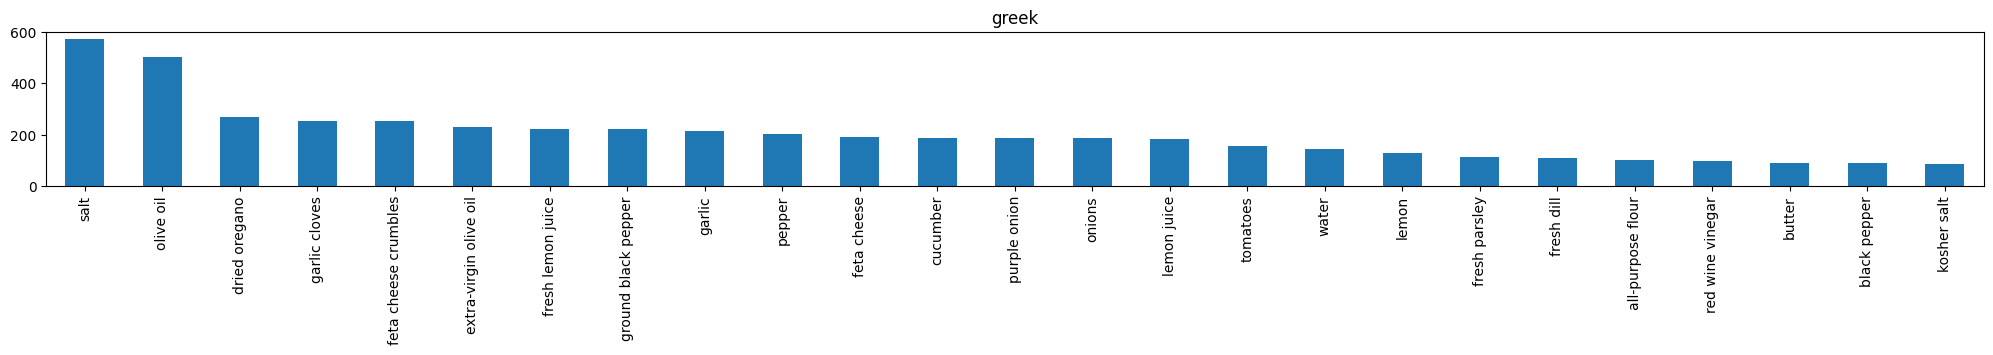

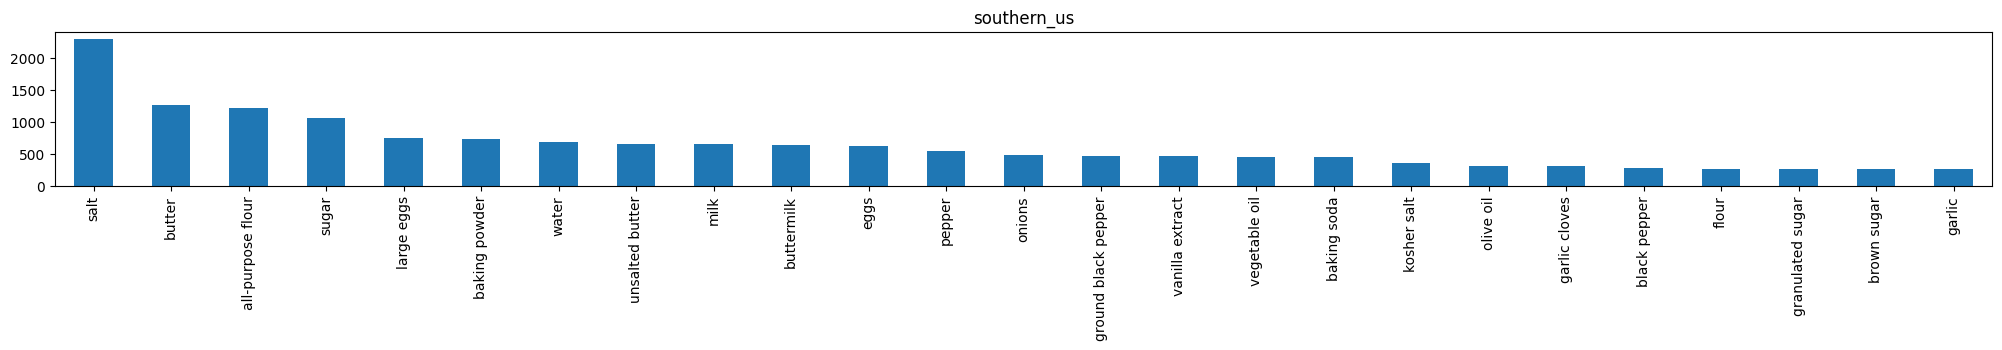

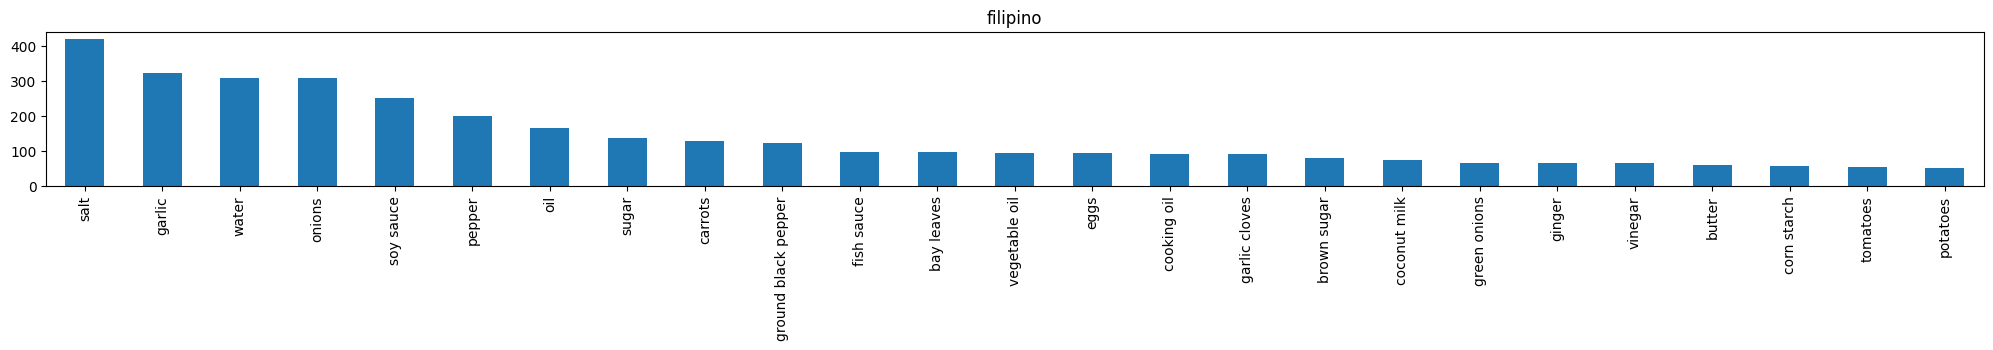

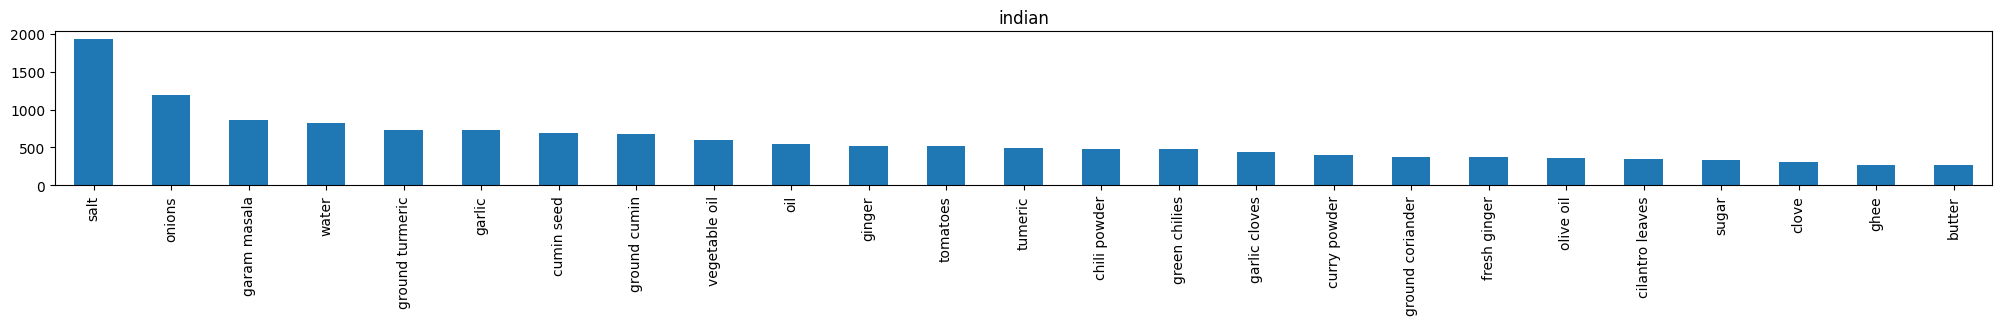

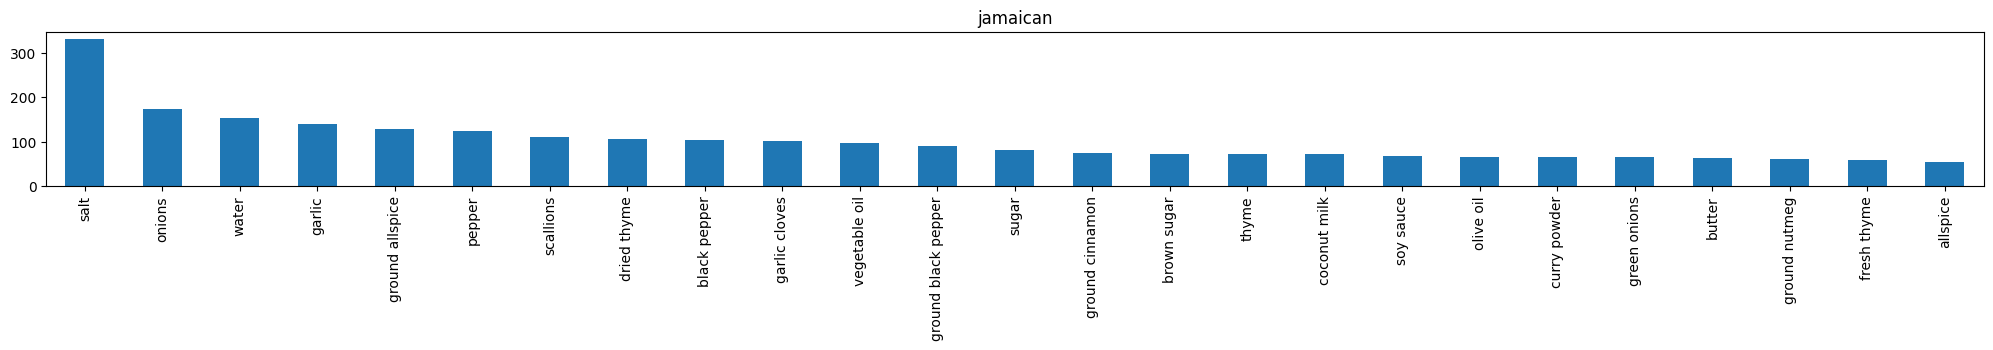

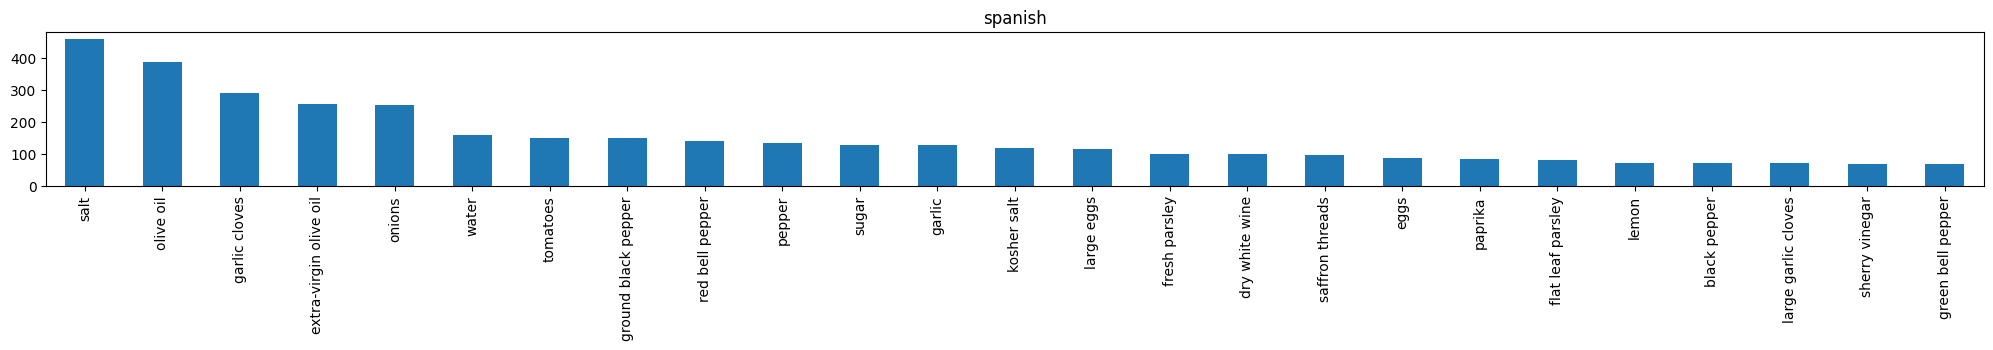

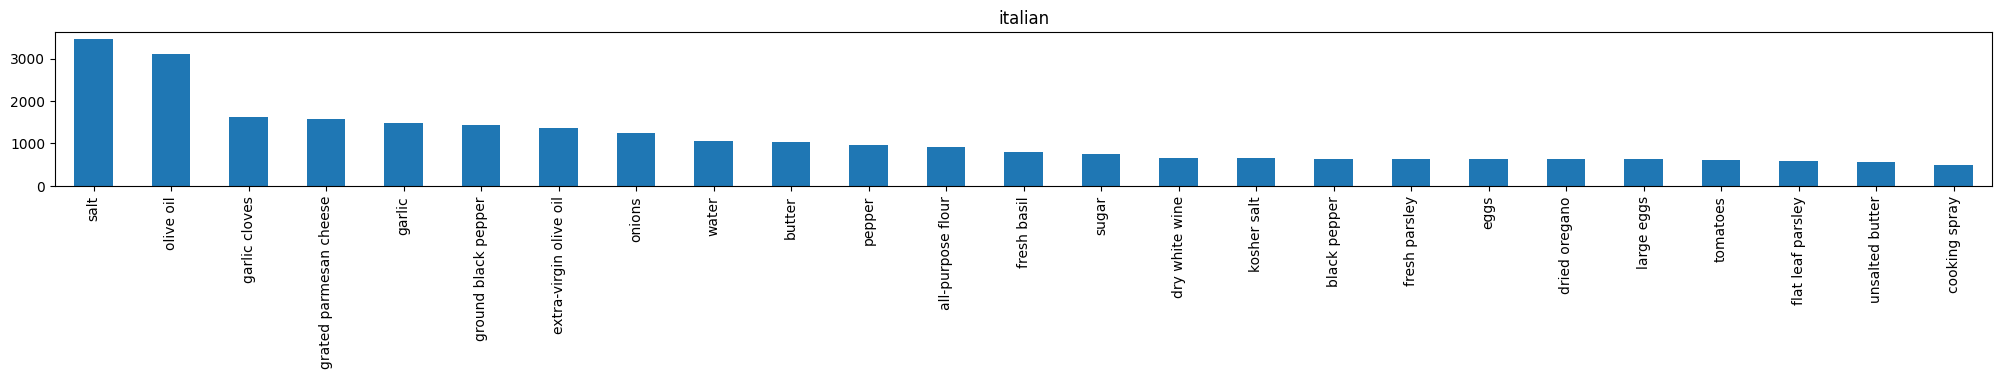

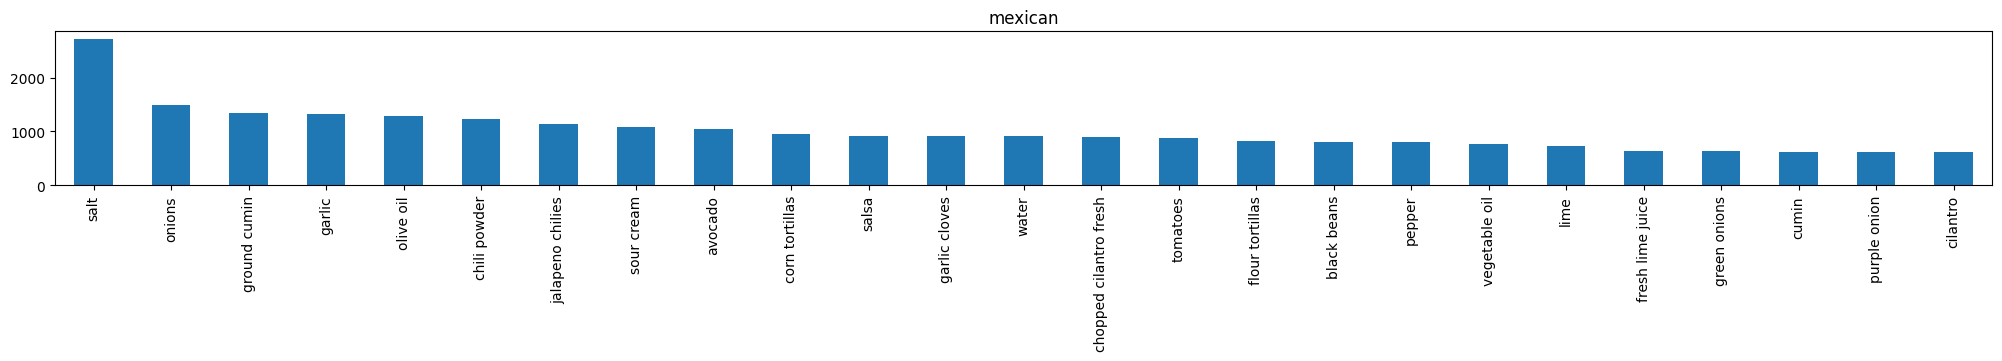

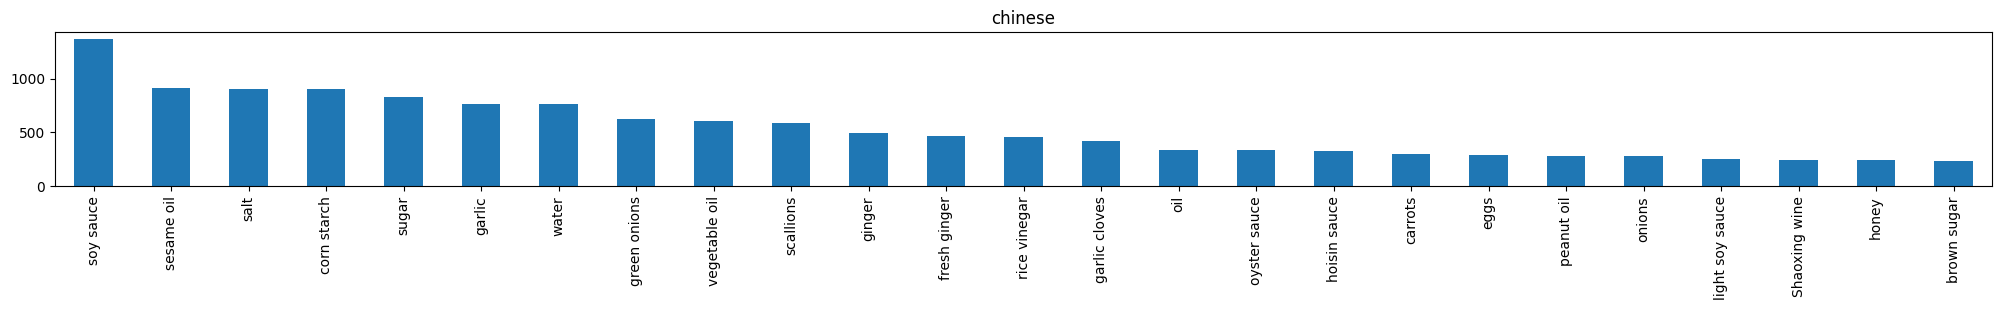

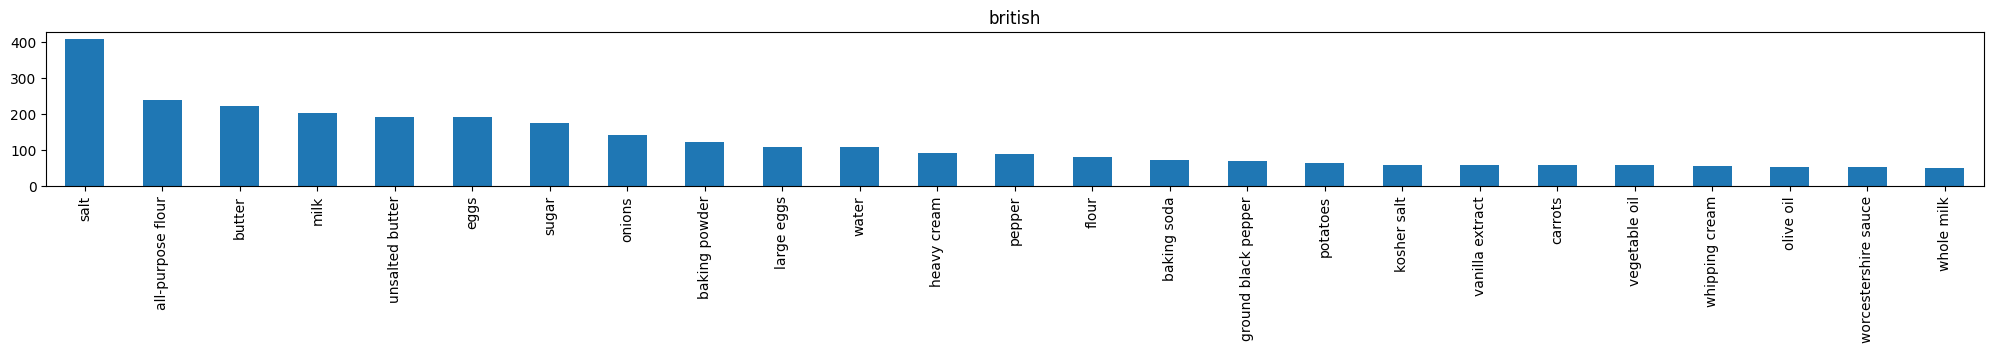

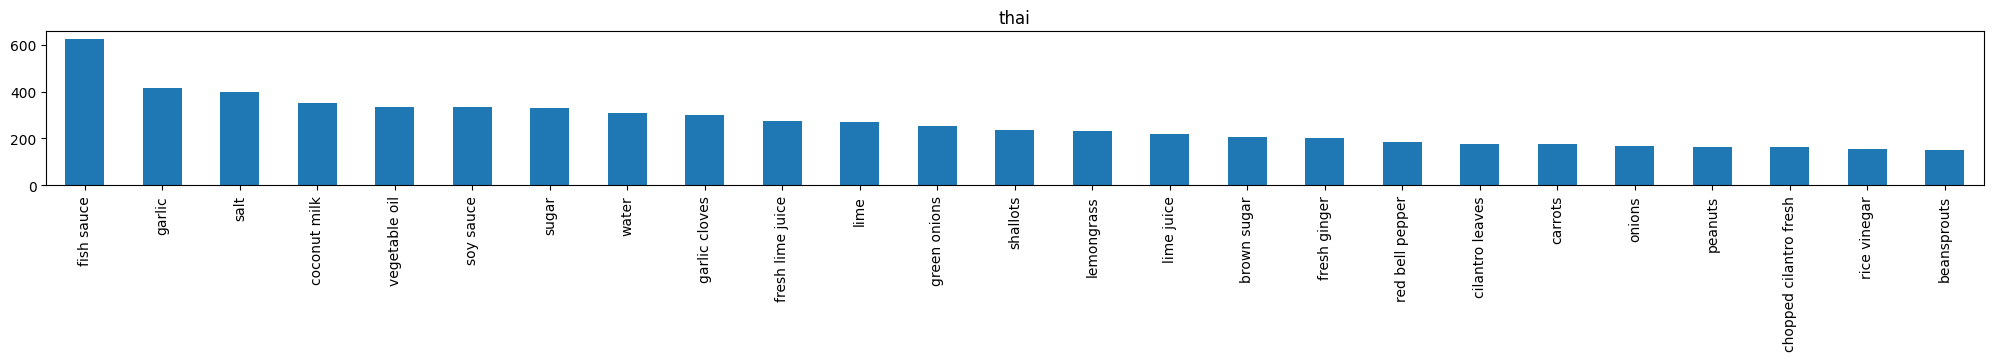

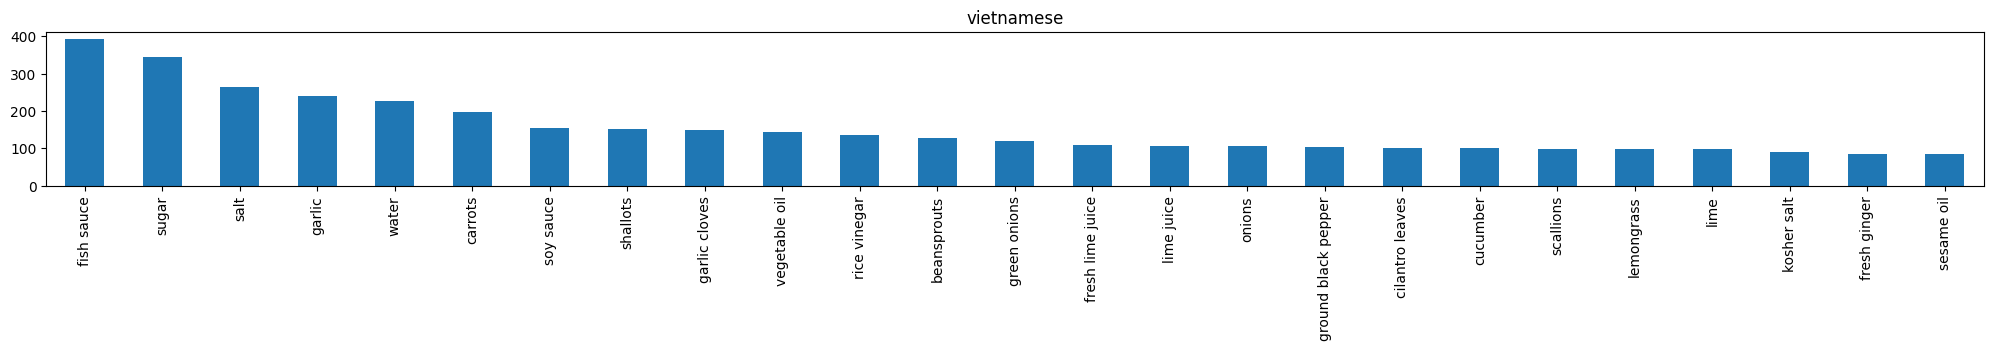

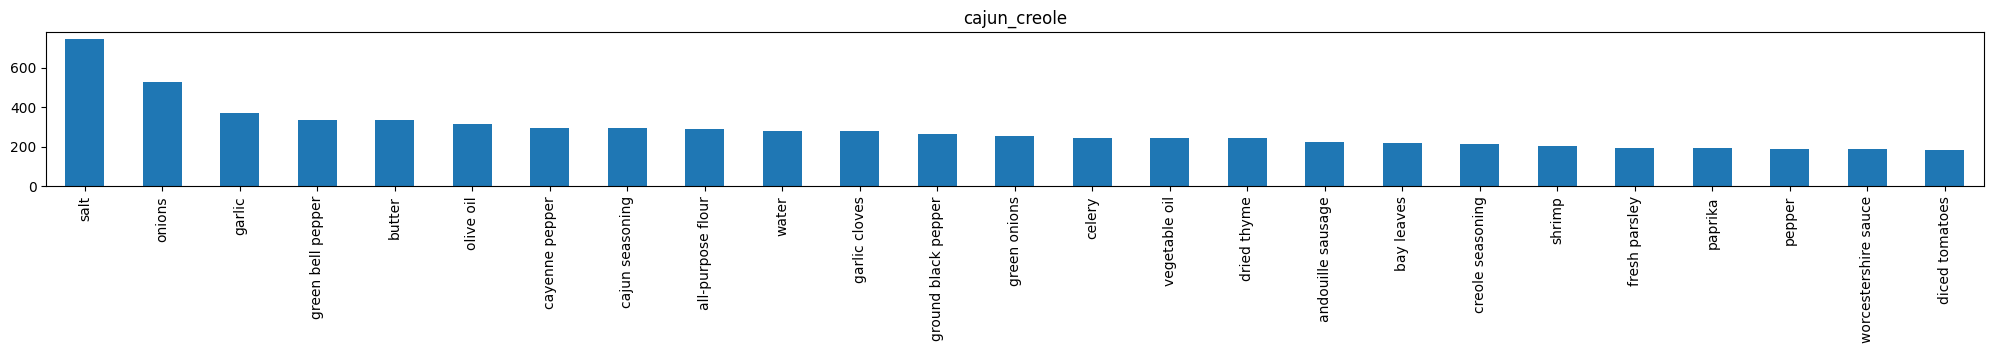

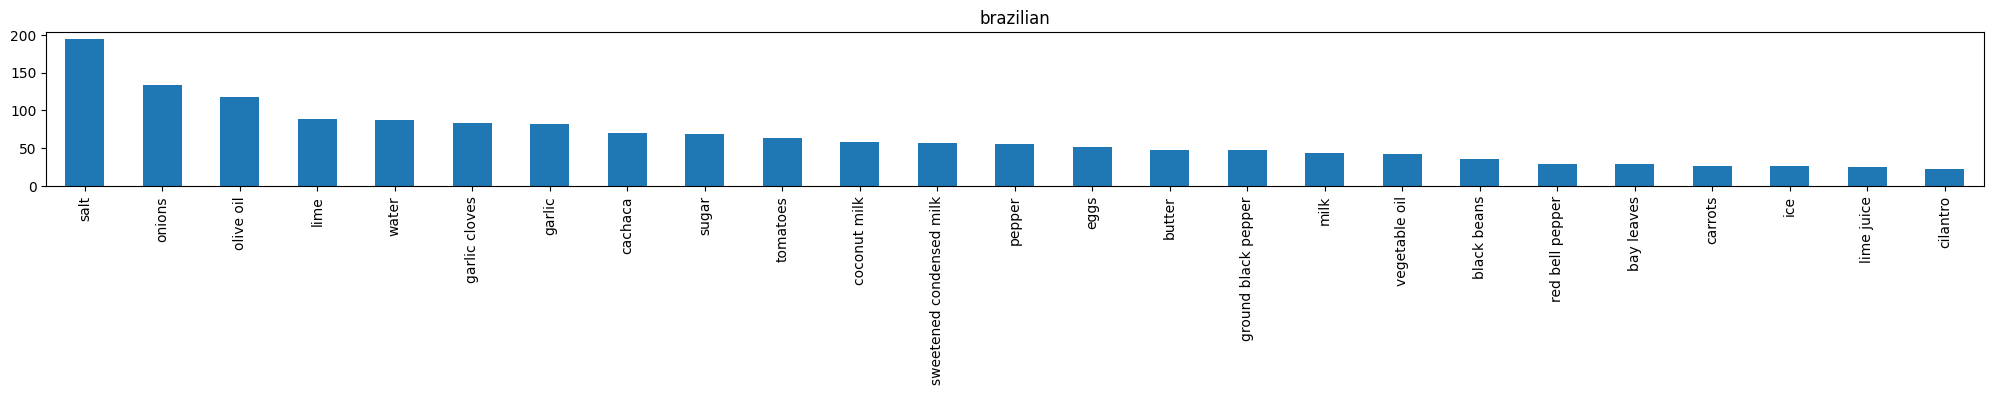

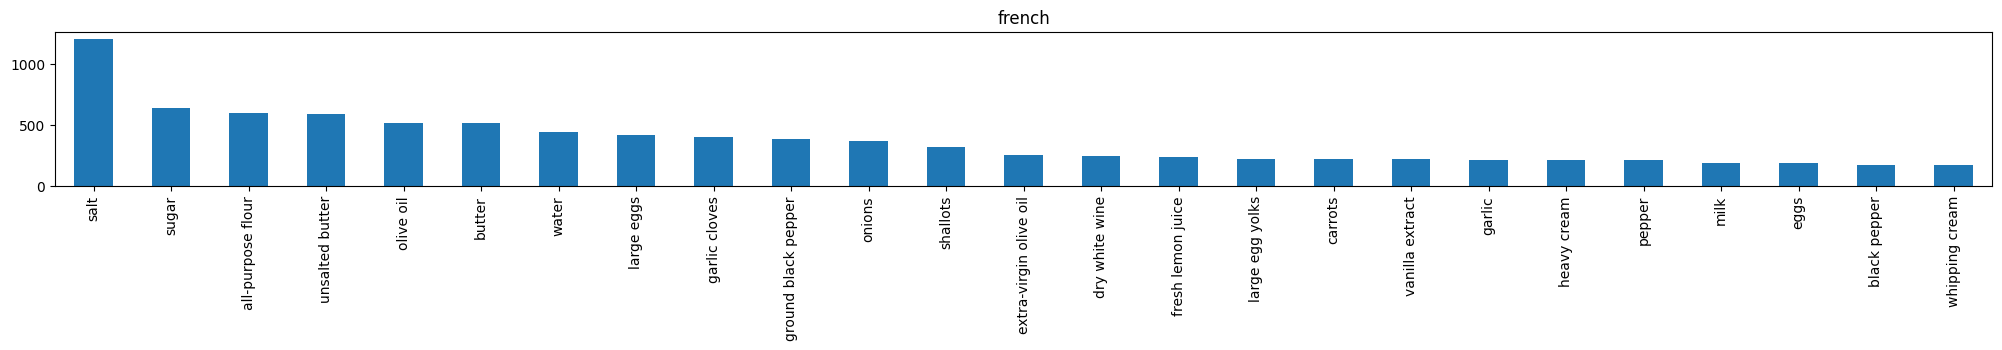

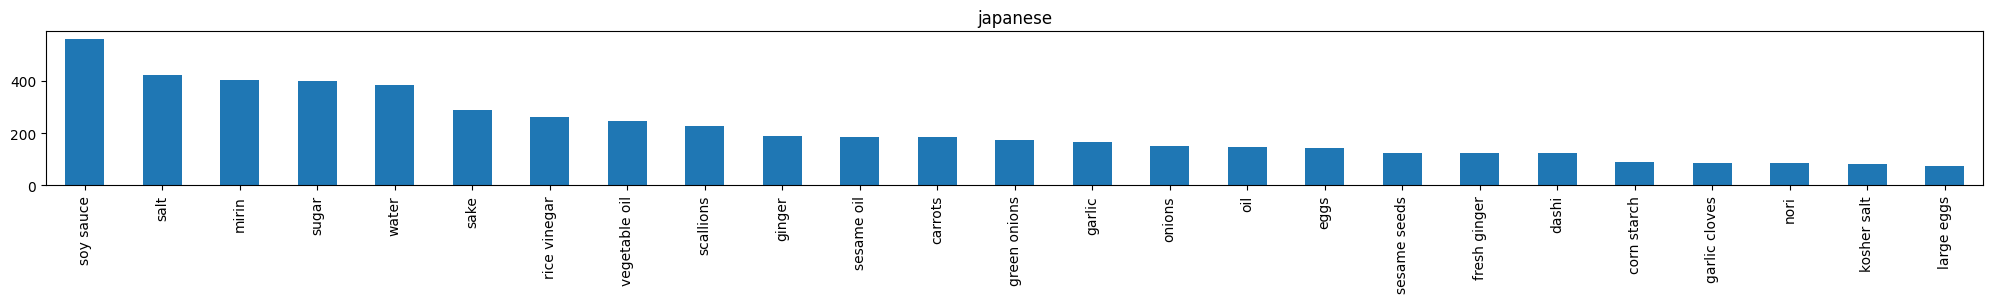

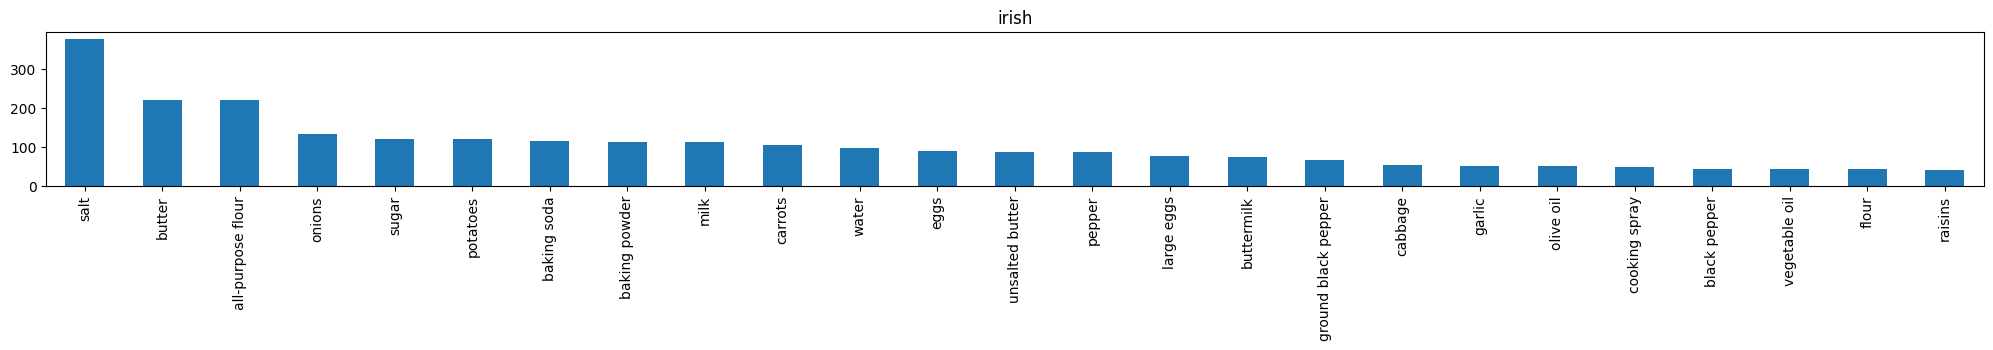

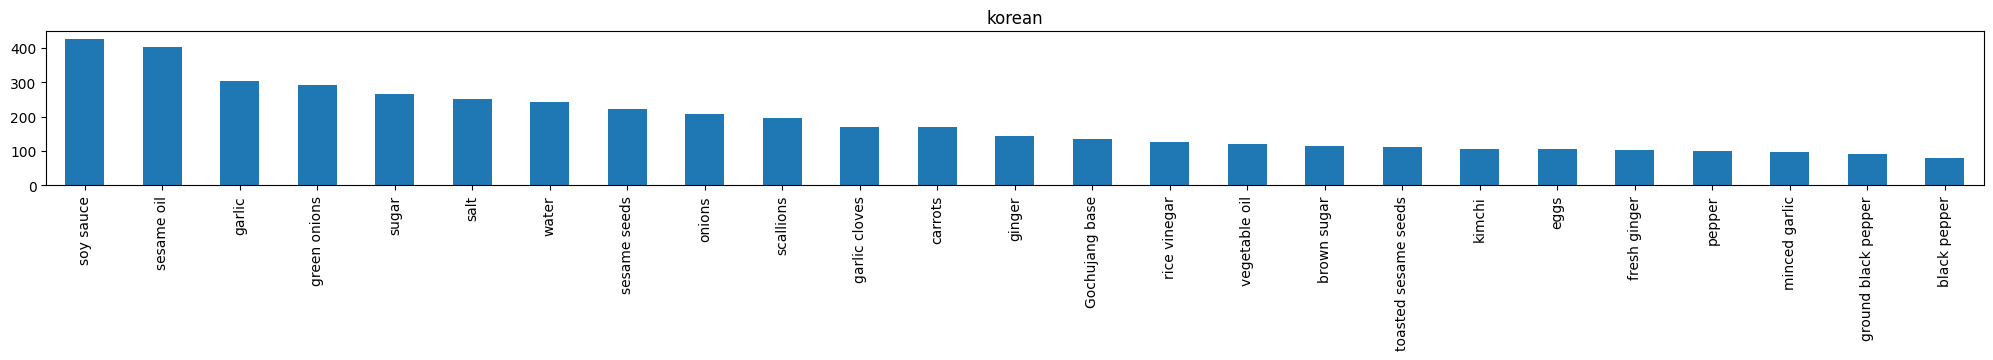

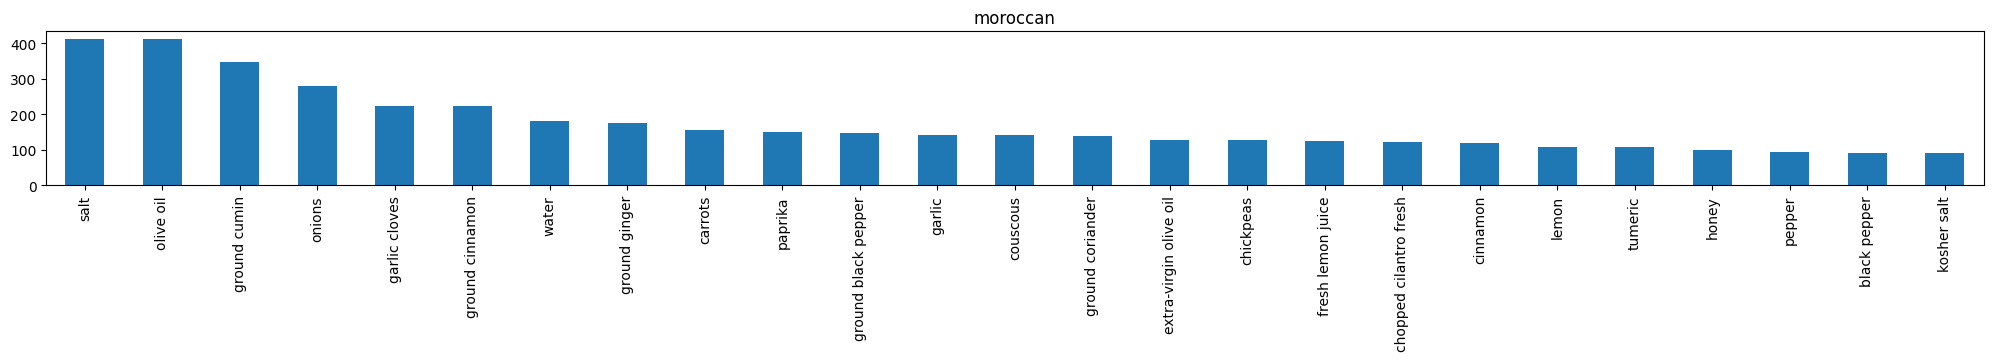

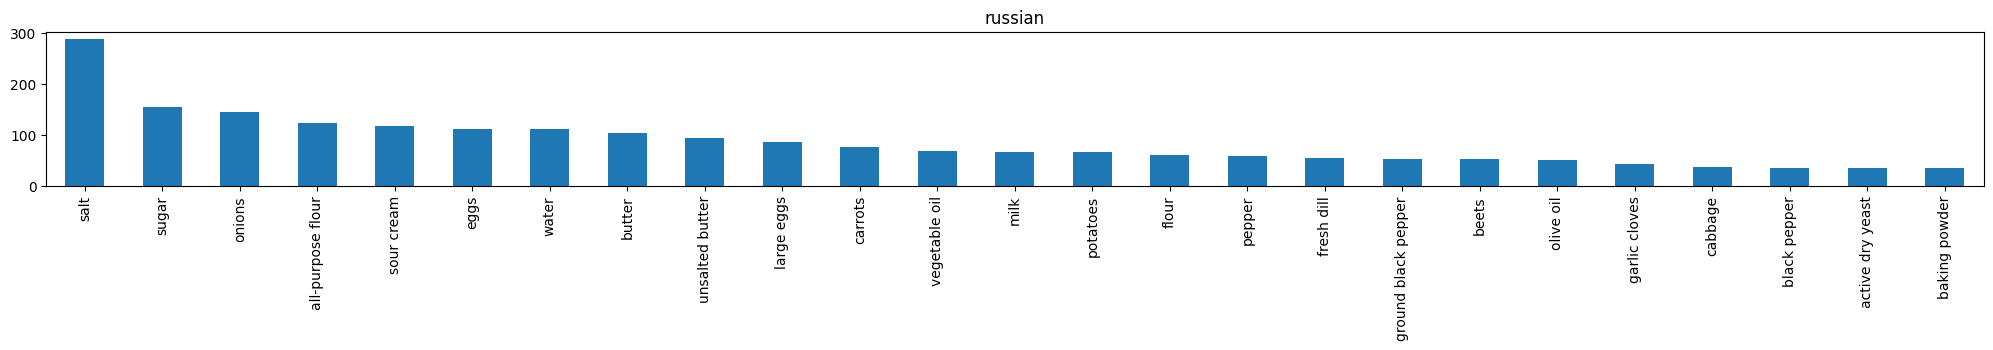

In [7]:
for key in all_cus.keys():
    fig, ax = plt.subplots(figsize=(25,2))
    pd.Series(all_cus[key]).value_counts().head(25).plot.bar(ax=ax, title=key)
    plt.show()

In [8]:
# Preprocessing function to clean and standardize ingredient text
def preprocess_df(df):
    def process_string(x):
        # if ingredients is a string instead of a list, convert it to a list first
        if isinstance(x, str):
            x = x.split(',')
        
        # Lemmatization: reduce words to their base form e.g. 'chopped' -> 'chop'
        x = [" ".join([WordNetLemmatizer().lemmatize(q) for q in p.split()]) for p in x] 

        # Remove common descriptive words that don't help identify cuisine e.g. 'crushed', 'minced'
        x = list(map(lambda x: re.sub(r'\(.*oz.\)|crushed|crumbles|ground|minced|powder|chopped|sliced','', x), x))
        
        # Remove numbers and special characters
        x = list(map(lambda x: re.sub("[^a-zA-Z]", " ", x), x))  

        # Join list of ingredients into a single string for vectorization
        x = " ".join(x)  

        # Convert to lowercase for consistency
        x = x.lower()
        return x

    # Drop id column as it is not needed for model training
    df = df.drop('id',axis=1)

    # Apply preprocessing to every recipe's ingredient list
    df['ingredients'] = df['ingredients'].apply(process_string)
    
    return df

# Combines all ingredients for each cuisine into one string
# Useful for analysis of which ingredients are most common per cuisine
def get_cuisine_cumulated_ingredients(df):
    cuisine_df = pd.DataFrame(columns=['ingredients'])

    for cus in cuisine:
        st = ""
        for x in df[df.cuisine == cus]['ingredients']:
            st += x
            st += " "
        cuisine_df.loc[cus,'ingredients'] = st

    cuisine_df = cuisine_df.reset_index()
    cuisine_df = cuisine_df.rename(columns ={'index':'cuisine'})
    return cuisine_df


In [9]:
# Get list of all unique cuisines before preprocessing 
# This is needed by get_cuisine_cumulated_ingredients() later
cuisine = recipe["cuisine"].unique()

# Apply preprocessing to the dataset, cleans and standardizes ingredient text
recipe = preprocess_df(recipe)
print(recipe)

#Combine all ingredients per cuisine into one strong for analysis
cuisine_df = get_cuisine_cumulated_ingredients(recipe)
print(cuisine_df)


           cuisine                                        ingredients
0            greek  romaine lettuce black olive grape tomato garli...
1      southern_us  plain flour  pepper salt tomato  black pepper ...
2         filipino  egg pepper salt mayonaise cooking oil green ch...
3           indian                     water vegetable oil wheat salt
4           indian  black pepper shallot cornflour cayenne pepper ...
...            ...                                                ...
39769        irish  light brown sugar granulated sugar butter warm...
39770      italian  kraft zesty italian dressing purple onion broc...
39771        irish  egg citrus fruit raisin sourdough starter flou...
39772      chinese  boneless chicken skinless thigh  garlic steame...
39773      mexican  green chile jalapeno chilies onion  black pepp...

[39774 rows x 2 columns]
         cuisine                                        ingredients
0          greek  romaine lettuce black olive grape tomato garli..

In [10]:
# Separate features (ingredients) and target (cuisine) from the preprocessed dataset
X = recipe['ingredients']
y = recipe['cuisine']

# Split data into 70% training and 30% testing
# random_state=42 ensures everyone gets the same split when they run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# TF-IDF Vectorizer: converts ingredient text into numerical vectors for the model
# TF-IDF highlights ingredients that are distinctive to a cuisine while down-weighting common ingredients like 'salt' and 'water'
def tfidf_vectorizer(train, test=None):
    tfidf = TfidfVectorizer(
        stop_words='english',             # removes common English words
        ngram_range = ( 1 , 1 ),          # considers single words only
        analyzer="word",                  # splits text by word
        max_df = .57,                     # ignores ingredients appearing in more than 57% of recipes
        binary=False,                     # uses frequency counts rather than just 0/1
        token_pattern=r'\w+',             # defines a word as any alphanumeric sequence
        sublinear_tf=False)               # uses raw frequency without log scaling

    # fit_transform on training data, learns vocabulary then encodes it
    train = tfidf.fit_transform(train)
    if test is not None:
        # transform only on test data, uses vocab learned from training data
        # never fit on test data as this would leak info into the model
        test = tfidf.transform(test)
        return train, test, tfidf
    else:
        return train, tfidf

In [12]:
# Apply TF-IDF vectorization to the train and test sets
# train_tfidf and test_ifidf are the numerical matrices passed into the model
train_tfidf, test_tfidf, tfidf = tfidf_vectorizer(X_train,X_test)

# Apply TF-IDF separately to the cuisine-cumulated dataset
# This is used for analysis purposes only, not for model training
# cuisine_data_tfidf, cuisine_tfidf = tfidf_vectorizer(cuisine_df['ingredients'])

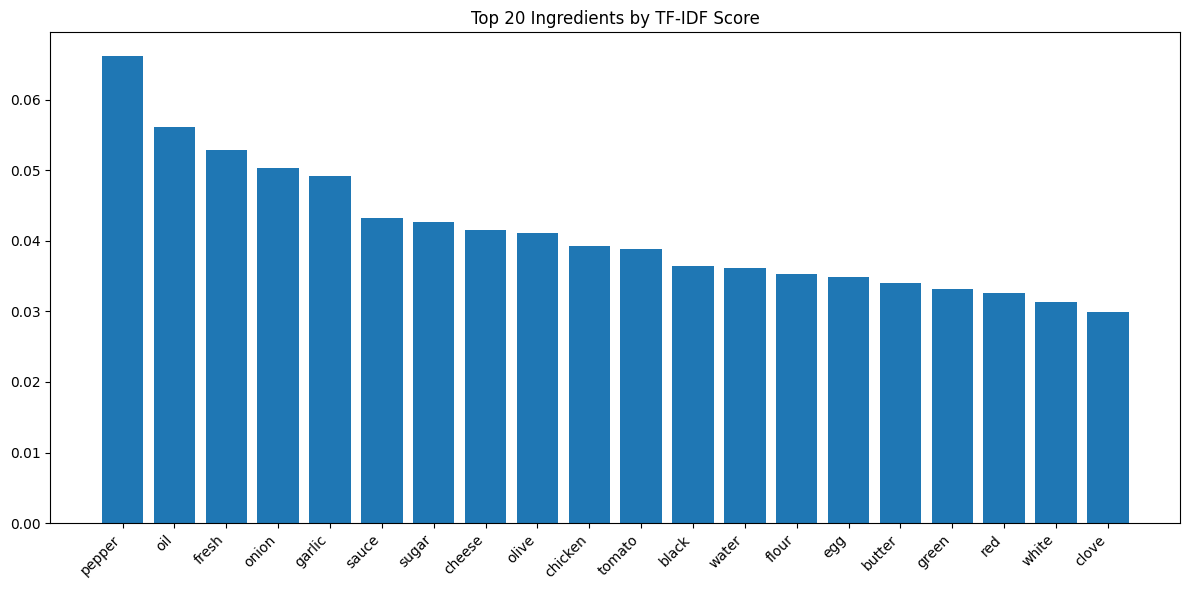

In [13]:
# Visualization: Top 20 ingredients by TF-IDF score
# Helps verify the vectorizer is working correctly by showing the most distinctive ingredients

# Extract the vocab learned by TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Calculate the average TF-IDF score for each ingredient across all recipes
mean_scores = train_tfidf.mean(axis=0).A1  

# Get the indices of the top 20 highest scoring ingredients
top_n = min(20, len(mean_scores))
top_indices = mean_scores.argsort()[-top_n:][::-1]

# Plot the top 20 ingredients as a bar chart
plt.figure(figsize=(12,6))
plt.bar(range(top_n), mean_scores[top_indices])
plt.xticks(range(top_n), feature_names[top_indices], rotation=45, ha='right')
plt.title('Top 20 Ingredients by TF-IDF Score')
plt.tight_layout()
plt.show()